# 2025 QS Ranking Visualization

## 1.Background

In an era of intensifying global competition in education, university rankings have become a vital benchmark for measuring academic excellence, teaching quality, and international influence. As one of the most authoritative assessments in the field, the QS World University Rankings is not only closely watched by universities worldwide but also serves as a key basis for governments, enterprises, and stakeholders to evaluate institutional strength. Therefore, conducting an in-depth analysis and visualization of QS ranking data is of paramount importance for a comprehensive understanding of the current status and evolving trends in global higher education.

With the acceleration of globalization and the rise of the knowledge economy, there are higher demands for quality and international impact in higher education. Competition among universities has become increasingly fierce, requiring excellence not only in teaching and research but also in internationalization and global cooperation. The QS World University Rankings provides a comprehensive platform for evaluation, covering metrics such as academic reputation, employer reputation, faculty-student ratios, and citation counts, which accurately reflect the core competitiveness of institutions across multiple dimensions.

Through the visual analysis of QS ranking data, we can intuitively explore performance disparities across different countries and regions, uncovering the underlying factors and trends in various academic disciplines. Furthermore, analyzing scores across specific indicators allows for an assessment of institutional strengths and weaknesses in teaching, research, and internationalization. These analytical insights not only provide essential reference and decision support for global higher education development but also foster international collaboration and drive collective progress in the field.

## 2.Dataset

**QS World University Rankings 2025**

- Overview:
This dataset provides a comprehensive overview of the QS World University Rankings for the year 2025, encompassing data on over 1,500 universities from 105 education systems worldwide. It includes institutional characteristics, regional classification, and a variety of performance indicators that reflect academic reputation, employability, sustainability, and internationalization.

- Dataset Details:
The dataset includes institutional rankings for both 2025 and 2024, alongside scores and ranks for numerous metrics used to evaluate universities. These metrics offer insight into academic quality, research output, international engagement, and employment outcomes.

Schema and Column Descriptions:<br>
RANK_2025: University’s overall rank in the 2025 QS World University Rankings<br>
RANK_2024: University’s overall rank in the 2024 QS Rankings<br>
Institution_Name: Name of the university or institution<br>
Location: Country in which the institution is located<br>
Region: Global region (e.g., Europe, Asia, North America)<br>
SIZE: Size classification of the institution (e.g., S, M, L, XL)<br>
FOCUS: Focus type (e.g., Comprehensive, Focused)<br>
RES.: Research intensity (e.g., Very High, High)<br>
STATUS: Status of the institution, with A representing public, B representing private not for profit, and C representing private for profit<br>
Academic_Reputation_Score: Score based on global academic reputation survey<br>
Academic_Reputation_Rank: Rank based on academic reputation<br>
Employer_Reputation_Score: Score based on global employer reputation survey<br>
Employer_Reputation_Rank: Rank based on employer reputation<br>
Faculty_Student_Score: Score reflecting student-to-faculty ratio<br>
Faculty_Student_Rank: Rank based on faculty-student ratio<br>
Citations_per_Faculty_Score: Score reflecting research impact (citations per faculty)<br>
Citations_per_Faculty_Rank: Rank based on citations per faculty<br>
International_Faculty_Score: Score representing international diversity of faculty<br>
International_Faculty_Rank: Rank based on international faculty presence<br>
International_Students_Score: Score representing diversity of international students<br>
International_Students_Rank: Rank based on international student ratio<br>
International_Research_Network_Score: Score based on global research collaboration<br>
International_Research_Network_Rank: Rank based on international research partnerships<br>
Employment_Outcomes_Score: Score reflecting graduates’ employability and success<br>
Employment_Outcomes_Rank: Rank based on employment outcomes<br>
Sustainability_Score: Score reflecting sustainability initiatives and performance<br>
Sustainability_Rank: Rank based on sustainability measures<br>
Overall_Score: Final composite score used to determine the university's ranking<br>

## 3.Import Data

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import plotly.graph_objects as go
import plotly.express as px
from wordcloud import WordCloud
import country_converter as coco


df = pd.read_csv('/Users/allisonxu/OneDrive/DS_Projects/25QS_Visualization/QS_2025.csv', encoding='ISO-8859-1')
df.head()

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7


In [34]:
df.shape

(1503, 28)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             1503 non-null   object 
 1   RANK_2024                             1482 non-null   object 
 2   Institution_Name                      1503 non-null   object 
 3   Location                              1503 non-null   object 
 4   Region                                1503 non-null   object 
 5   SIZE                                  1503 non-null   object 
 6   FOCUS                                 1503 non-null   object 
 7   RES.                                  1503 non-null   object 
 8   STATUS                                1466 non-null   object 
 9   Academic_Reputation_Score             1503 non-null   float64
 10  Academic_Reputation_Rank              1503 non-null   object 
 11  Employer_Reputati

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Academic_Reputation_Score,1503.0,20.286693,22.326168,1.3,6.300,11.00,23.5,100.0
Employer_Reputation_Score,1503.0,19.787292,23.784738,1.1,4.300,9.40,25.3,100.0
Faculty_Student_Score,1503.0,28.128676,27.613017,1.0,7.300,16.00,40.4,100.0
Citations_per_Faculty_Score,1503.0,23.503460,27.870692,1.0,2.800,9.90,36.4,100.0
International_Faculty_Score,1403.0,30.736707,34.344365,1.0,4.200,12.50,51.6,100.0
International_Students_Score,1445.0,25.580346,31.098689,1.0,2.900,9.60,38.3,100.0
International_Research_Network_Score,1502.0,50.129095,29.866588,1.0,22.725,51.10,77.1,100.0
Employment_Outcomes_Score,1503.0,23.825083,27.351315,1.2,4.000,11.80,33.4,100.0
Sustainability_Score,1484.0,24.309299,31.074718,1.0,1.300,6.75,39.5,100.0


**Data Cleaning**

In [37]:
categorical_cols = ['Institution_Name', 'Location', 'Region', 'SIZE', 'FOCUS', 'RES.', 'STATUS']

def convert_to_int(df):
    for col in df.columns:
        if col not in categorical_cols:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.extract('(\d+)')
            
            temp_numeric = pd.to_numeric(df[col], errors='coerce')
            
            df[col] = temp_numeric.dropna().astype(float).astype(int).reindex(df.index)
            df[col] = df[col].astype('Int64')
    return df

def clean_data(df):
    df = df.dropna()
    rank_df = df[['RANK_2025', 'RANK_2024']]
    cat_df = df[categorical_cols]
    score_cols = [col for col in df.columns if 'score' in col.lower()]
    score_df = df[score_cols]

    df = convert_to_int(df)

    rank_change = df['RANK_2024'] - df['RANK_2025']
    df = df.assign(Rank_Change = rank_change)
    return df
df = clean_data(df)
df.head()

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score,Rank_Change
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100,...,86,143,96,58,100,8,99,15,100,0
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98,...,99,44,97,34,93,61,99,6,98,4
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100,...,97,73,100,1,100,3,85,126,96,0
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100,...,69,215,99,5,100,1,84,130,96,0
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100,...,94,98,99,10,100,5,84,127,96,-3


# 4.Data Visualization

---

**Global Heatmap of University Locations**

In [38]:
country_codes = pd.Series(coco.convert(df['Location'], to = 'ISO3'))
university_location = country_codes.value_counts()

fig = px.choropleth(
    width=800, height=500, 
    locations = university_location.index, 
    color = university_location.values, 
    color_continuous_scale = px.colors.sequential.YlOrRd, 
    template = 'plotly_white', 
    title = 'University Location Distribution Map'
)

fig.show()

Most universities are located in the United States, China, Australia, Canada, and Russia. 

---

**Distribution of University Categorical Attributes**

In [39]:
row_n = 2
col_n = 2
fig = make_subplots(rows = row_n, cols = col_n)

size_counts = df['SIZE'].value_counts().sort_values()
focus_counts = df['FOCUS'].value_counts().sort_values()
rs_counts = df['RES.'].value_counts().sort_values()
status_counts = df['STATUS'].value_counts().sort_values()

categorical_lst = [size_counts, focus_counts, rs_counts, status_counts]
categorical_labels = ['Size', 'Focus', 'Research', 'Status']

for i, col in enumerate(categorical_labels):
    fig.add_trace(
        go.Bar(
            x = categorical_lst[i].index.astype('str'), 
            y = categorical_lst[i].values, 
            name = col, 
            text = np.round(categorical_lst[i].values, 3), 
            textposition = 'auto', 
            marker = dict(
                color = categorical_lst[i].values, 
                colorscale = 'Blues',
                showscale = False)),
        row = int(i/col_n)+1, 
        col = int(i%col_n)+1)

fig.update_layout(
    title_text = 'Distribution of Categorical Variables', 
    template = 'plotly_white')

fig.update_traces(marker_line_color = 'black', 
                  marker_line_width = 1.5, 
                  opacity = 0.8)

fig.show()

Most top ranking universities have the following characteristics: 
 * Between 12,000 to 30,000 students; 
 * Full comprehensive;
 * Very high research intensity;
 * Public.

---

**Top 20 Universities Word Cloud**

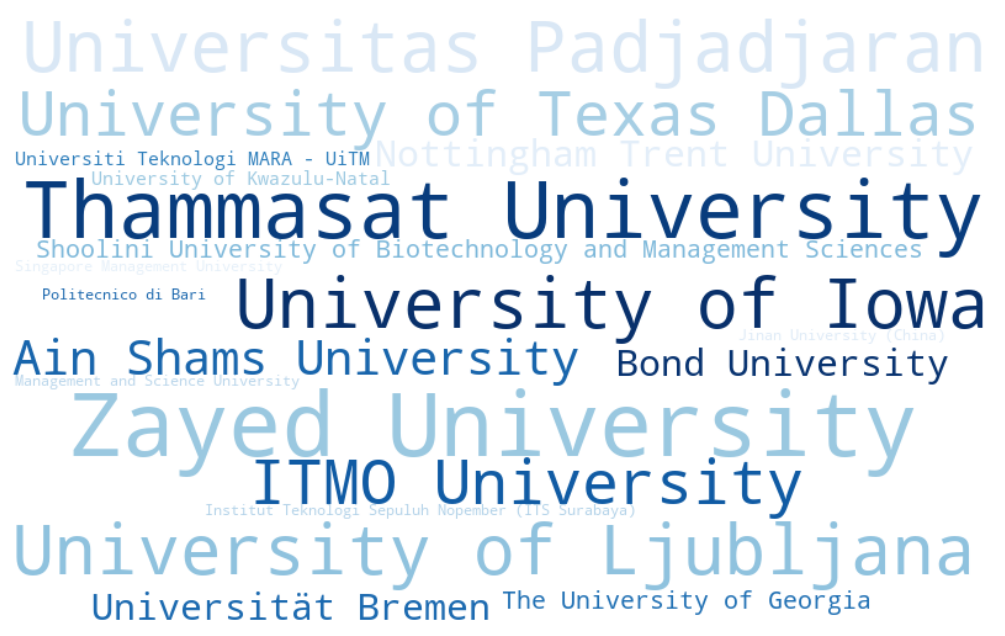

In [40]:
data = dict(zip(df['Institution_Name'].tolist(), df['RANK_2025'].tolist()))
plt.figure(figsize = (14, 8))
wc = WordCloud(width = 800, 
               height = 500, 
               max_words = 20, 
               colormap = 'Blues', 
               background_color = 'white').generate_from_frequencies(data)
plt.imshow(wc, interpolation = 'bilinear')

plt.axis('off')
plt.show()

---

**Ranking Flux: Top 20 Global Universities (2023–2024)**

In [41]:
top20_df = df.iloc[:21]
top20_rank_change = top20_df.set_index('Institution_Name')['Rank_Change'].sort_values()

fig = px.bar(
    x = top20_rank_change.index, 
    y = top20_rank_change.values, 
    text = top20_rank_change.values, 
    color = top20_rank_change.values, 
    color_continuous_scale = 'Cividis', 
    height = 600)

fig.update_layout(
    title_text = 'Top 20 University Rank Up & Down From 2024 to 2025', 
    template = 'plotly_white', 
    xaxis = dict(
        title = 'Institution Name', titlefont_size = 10, tickangle = 45), 
    yaxis = dict(
        title = 'Rank Change', titlefont_size = 12))

fig.update_traces(
    marker_line_color = 'black', 
    marker_line_width = 1.2, 
    opacity = 0.8)

fig.show()

* The "Stability" Zone: Several world-class institutions—such as MIT, UCL, and Imperial College London—show a rank change of 0 or near 0. This suggests that at the very pinnacle of global rankings, the "prestige ceiling" is high, and movement is difficult.
* Significant Gainers: Nanyang Technological University (NTU) (+11) and The University of Hong Kong (+9) show the most aggressive upward mobility. This points to a significant strengthening of Asian higher education hubs.
* Notable Declines: The University of Chicago experienced a sharp drop of -10.

---

**Country Rank Fluctuations**

In [42]:
rank_change_greatest = df.groupby('Location')['Rank_Change'].mean().sort_values(ascending = False)[:10]
rank_change_smallest = df.groupby('Location')['Rank_Change'].mean().sort_values(ascending = False)[-10:]
rank_change = pd.concat([rank_change_greatest, rank_change_smallest])

fig = px.bar(
    x = rank_change.index, 
    y = rank_change.values, 
    text = np.round(rank_change.values), 
    color = rank_change.values, 
    color_continuous_scale = 'PuBu', 
    width = 800, 
    height = 500)

fig.update_layout(
    title_text = 'Top 10 Countries Rank Increase & Decrease From 2024 to 2025', 
    template = 'simple_white', 
    xaxis = dict(
        title = 'Country', 
        titlefont_size = 12),
    yaxis = dict(
        title = 'Average Rank Change', 
        titlefont_size = 12))

fig.show()

- Jordan and Bangladesh emerged as the most improved nations, with substantial average rank increases of about 154 and 137, respectively. Conversely, Western nations such as France and the United States experienced the most pronounced declines, dropping 34 and 27 positions on average.
- Middle Eastern and South Asian countries dominate the positive growth segment, led by Jordan's 154-point surge. In contrast, the negative spectrum is characterized by established economies, with France seeing the sharpest decrease (-34).

In [43]:
row_n = 2
col_n = 2

fig = make_subplots(rows = row_n, cols = col_n)
change_by_size = df.groupby('SIZE')['Rank_Change'].mean().sort_values()
change_by_focus = df.groupby('FOCUS')['Rank_Change'].mean().sort_values()
change_by_rs = df.groupby('RES.')['Rank_Change'].mean().sort_values()
change_by_status = df.groupby('STATUS')['Rank_Change'].mean().sort_values()
change_by_categories = [change_by_size, change_by_focus, change_by_rs, change_by_status]

for i, col in enumerate(categorical_labels):
    fig.add_trace(
        go.Bar(
            x = change_by_categories[i].index.astype('str'), 
            y = change_by_categories[i].values, 
            name = col, 
            text = np.round(change_by_categories[i].values), 
            textposition = 'inside', 
            marker_color = px.colors.sequential.Teal), 
        row = int(i/col_n)+1, col = int(i%col_n)+1)

fig.update_layout(
    title_text = 'Average Rank Change by Categorical Variables', 
    template = 'simple_white', 
    height = 450, 
    width = 650)

fig.update_traces(
    marker_line_color = 'black', 
    marker_line_width = 1.2, 
    opacity = 0.6)

fig.show()

- Small-scale institutions (S), with populations between 12,000 and 30,000, had the most substantial growth in rankings. This suggests that mid-to-large sized campuses are currently experiencing the strongest upward momentum compared to their mega-campus counterparts (XL).
- 'Specialist' (SP) institutions, focusing on 2 or fewer faculty areas, exhibited the highest rank advancement. This outperformance highlights a growing market valuation for specialized, niche academic excellence over broad-based comprehensive universities.
- High research intensity (HI) universities are the clear frontrunners in the research category, which underscores a significant correlation between aggressive research output and institutional prestige gains.
- The most dramatic shift is observed in the 'Status' sector, where Private For-Profit (C) entities saw a 34-point average increase. This indicates a volatile yet aggressive trend of rapid ascent among for-profit institutions within the current ranking cycle.

---

**Overall Score**

In [44]:
top10_score_country = df.groupby('Location')['Overall_Score'].mean().sort_values(ascending = False)[:10]
low10_score_country = df.groupby('Location')['Overall_Score'].mean().sort_values()[:10]
overall_score_country = pd.concat([top10_score_country, low10_score_country])

fig = px.bar(
    x = overall_score_country.index, 
    y = overall_score_country.values, 
    color = overall_score_country.values, 
    color_continuous_scale = 'Inferno')

fig.update_layout(
    title_text = 'Top & Bottom 10 Countries of Average Overall Score', 
    template = 'simple_white', 
    xaxis = dict(
        title = 'Country', 
        titlefont_size = 12), 
    yaxis = dict(
        title = 'Average Overall Score', 
        titlefont_size = 12), 
    width = 900, 
    height = 450)

fig.show()

- Hong Kong SAR and Singapore lead the dataset significantly, being the only two regions to surpass the 60-point threshold in Average Overall Score.
- There is a stark contrast between the top-performing countries and the bottom-tier countries, with a score gap of approximately 50 points between the highest (Hong Kong SAR) and the lowest (Slovenia).
- There is also a notable performance gap between the top two leaders and the rest of the high-scoring group. For instance, there is a sharp decline of roughly 15 points moving from Singapore to Mexico.
- The bottom 10 countries show small variance in their scores, ranging tightly between approximately 20 and 28 points.

In [45]:
overall_score_country_lst = overall_score_country.index.tolist()
overall_score_country_df = df[df['Location'].apply(lambda x: x in overall_score_country_lst)]

fig = px.box(
    overall_score_country_df, 
    x = 'Location', 
    y = 'Overall_Score', 
    color = 'Location') 

fig.update_layout(
    title_text = 'Average Overall Score Deviations by Countries', 
    template = 'simple_white', 
    width = 900, 
    height = 400)
    
fig.show()

- High Dispersion in Top Tier: The United States, Switzerland, Singapore, and Australia exhibit significant variance, with scores spanning from roughly 20 to nearly 100.
- Outliers: Hong Kong SAR and the Netherlands both feature notable outliers. While Hong Kong SAR’s median is high, it has a significant downward outlier near 40, whereas the Netherlands shows an upward outlier above 75.
- Singapore displays a heavily negatively skewed distribution; while its maximum reaches nearly 95, the median is positioned much higher in the box, suggesting that most data points are clustered at the top end despite a long downward tail.
- Countries like Japan and Australia show a more symmetrical distribution, with the median line sitting near the center of the box, indicating a more balanced spread of scores.
- The bottom-ranking nations (from Lithuania to Slovenia) show minimal interquartile range (IQR), indicating highly consistent but low performance across the board.

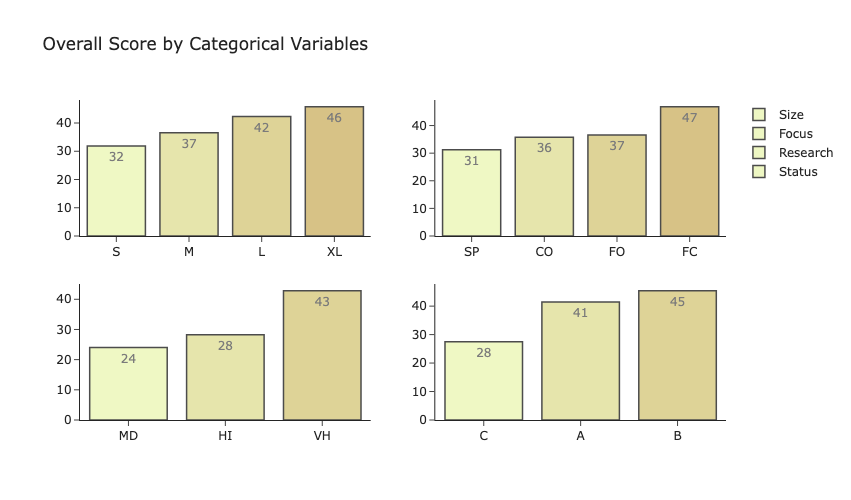

In [46]:
fig = make_subplots(rows = row_n, cols = col_n)

score_by_size = df.groupby('SIZE')['Overall_Score'].mean().sort_values()
score_by_focus = df.groupby('FOCUS')['Overall_Score'].mean().sort_values()
score_by_res = df.groupby('RES.')['Overall_Score'].mean().sort_values()
score_by_status = df.groupby('STATUS')['Overall_Score'].mean().sort_values()
score_by_categories = [score_by_size, score_by_focus, score_by_res, score_by_status]
for i, col in enumerate(categorical_labels):
    fig.add_trace(
        go.Bar(
            x = score_by_categories[i].index.astype('str'), 
            y = score_by_categories[i].values, 
            name = col, 
            text = np.round(score_by_categories[i].values), 
            marker_color = px.colors.sequential.turbid), 
        row = int(i/col_n)+1, col=int(i%col_n)+1)

fig.update_layout(
    title_text = 'Overall Score by Categorical Variables', 
    template = 'simple_white', 
    width = 600, 
    height = 500)

fig.update_traces(marker_line_color = 'black', 
                  marker_line_width = 1.5, 
                  opacity = 0.7)

fig.show()

- Larger-scale institutions may benefit from resource concentration, as evidenced by the consistent step-up in scores from Small (32) to Extra Large (46).
- There is a direct positive correlation between the number of faculty areas and the overall score; Specialist (SP) institutions with two or fewer faculty areas score the lowest at 31, while adding faculties (CO and FO) leads to a progressive score increase, and Full Comprehensive (FC) institutions achieve the highest average score of 47.
- Research intensity appears to be the most significant categorical driver of performance; 'VH' (Very High) research entities average a score of 43, nearly double the performance of 'MD' (Medium) entities (24).
- Public and Private not for profit institutions maintain a relatively high and stable performance (41 and 45 respectively) compared to Private for profit. 